# <center> Tests de différentes architectures EfficientNet

On compare ici différentes architectures avec exactement les mêmes hyperparamètres que pour ResNet18 c'est à dire :
- Même split train / val / test
- Même preprocessing
- Même nombre d’epochs
- Même optimizer (Adam)
- Même early stopping

Stratégie en 2 phases :

Phase 1 — Head-only training (comme ResNet18, on freeze tous les paramètres du modèle et on entraine uniquement la couche finale)
→ Permet comparaison équitable

Phase 2 — Fine-tuning partiel (optionnel mais intéressant, on débloque les 1-2 dernières couches mais risque de surapprentissage)
→ Permet voir si les performances stagnent à cause du gel



Nous nous consacrons dans ce notebook à tester différents arcitecture EfficientNet :  
- EfficientNet-B0  
- EfficientNet-B1   

Normalement EfficientNet équilibre parfaitement la profondeur, la largeur et la résolution de l'image.

### 0. Préparation des hyper-paramètres et du dataset

#### Imports de base

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import sys
from pathlib import Path

# Pour que notre archi fonctionne avec google colab

!git clone https://github.com/julietteabalain-cloud/Reconnaissance-de-mouvement-artistique.git
!cd /content/Reconnaissance-de-mouvement-artistique && git pull
%cd /content/Reconnaissance-de-mouvement-artistique
import sys
sys.path.append(".")  # pour que src/ soit importable

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
DATA_ROOT = PROJECT_ROOT / "data"

Cloning into 'Reconnaissance-de-mouvement-artistique'...
remote: Enumerating objects: 531, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 531 (delta 36), reused 45 (delta 20), pack-reused 469 (from 1)
Receiving objects: 100% (531/531), 94.69 MiB | 13.52 MiB/s, done.
Resolving deltas: 100% (343/343), done.
Already up to date.
/content/Reconnaissance-de-mouvement-artistique


In [ ]:
from src.dataset_dl import ArtDataset
from src.train import train_model, train_one_epoch, validate_one_epoch

from src.dataset import load_df_train_test_val, load_df
from src.preprocessing import clean_dataset

from src.models import get_model
from src.evaluate import *
from src.utils import set_seed

#Fixer l'initialisation aléatoire pour la reproductibilité
set_seed(42)

#pour avoir acces au GPU si dispo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

PROJECT_ROOT = Path("/content/deepl-projet")
DATA_ROOT = Path("/content/drive/MyDrive/DeepLearning/WikiArt_Subset")


df_test, df_train, df_val = load_df_train_test_val(DATA_ROOT)
df = load_df(DATA_ROOT)

df, df_train, df_val, df_test = clean_dataset(df, df_train, df_val, df_test)

Mounted at /content/drive


/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["style_encoded"] = dataset["style_name"].map(style_to_idx)
/content/Reconnaissance-de-mouvement-artistique/src/preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

#### Dataset de deep learning

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # ajout de data augmentation pour le training set
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [ ]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,     # ajuster selon ton CPU
    pin_memory=True
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

### 1. EfficientNet B0/B1

→ Scaling composé (profondeur + largeur + résolution)
→ Très efficace en vision

Une architecture optimisée moderne améliore-t-elle la reconnaissance stylistique ?

#### 3.1 Charger le modèle

In [ ]:
model_b0 = get_model("efficientnet_b0", num_classes=23)
model_b0 = model_b0.to(device)
model_b1 = get_model("efficientnet_b1", num_classes=23)
model_b1 = model_b1.to(device)

num_classes = df_train["style_encoded"].nunique()

# ajout de label smoothing pour la cross entropy loss
# label smoothing permet de rendre le modèle moins confiant dans ses prédictions,
# ce qui peut aider à améliorer la généralisation et réduire le surapprentissage
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_b0 = torch.optim.Adam(
    model_b0.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

optimizer_b1 = torch.optim.Adam(
    model_b1.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

## compter le nb de param
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model_b0))
print("Trainable parameters:", count_parameters(model_b1))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 189MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 206MB/s]


Trainable parameters: 29463
Trainable parameters: 29463


#### 3.2 Entrainement

In [ ]:
# from src.utils import EarlyStopping

early_stopping = EarlyStopping(patience=3)

NUM_EPOCHS_FREEZE = 10
history_freeze_b0 = train_model(
    model_b0,
    train_loader,
    val_loader,
    criterion,
    optimizer_b0,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)



Epoch 1/10


Train Loss: 2.5832 | Train Acc: 0.2779 | Val Loss: 2.2555 | Val Acc: 0.3991

Epoch 2/10


Train Loss: 2.1729 | Train Acc: 0.4176 | Val Loss: 2.1551 | Val Acc: 0.4217

Epoch 3/10


Train Loss: 2.0478 | Train Acc: 0.4641 | Val Loss: 2.1081 | Val Acc: 0.4465

Epoch 4/10


Train Loss: 1.9808 | Train Acc: 0.4903 | Val Loss: 2.0953 | Val Acc: 0.4450

Epoch 5/10


...

Train Loss: 1.8972 | Train Acc: 0.5218 | Val Loss: 2.0844 | Val Acc: 0.4508

Epoch 7/10


Train Loss: 1.8638 | Train Acc: 0.5337 | Val Loss: 2.0959 | Val Acc: 0.4596

Epoch 8/10


Train Loss: 1.8352 | Train Acc: 0.5463 | Val Loss: 2.0810 | Val Acc: 0.4545

Epoch 9/10


Train Loss: 1.8060 | Train Acc: 0.5598 | Val Loss: 2.1067 | Val Acc: 0.4355

Epoch 10/10


Train Loss: 1.7796 | Train Acc: 0.5683 | Val Loss: 2.0903 | Val Acc: 0.4567
Meilleur modèle restauré (val_loss=2.0810)


#### 3.3 Evaluation

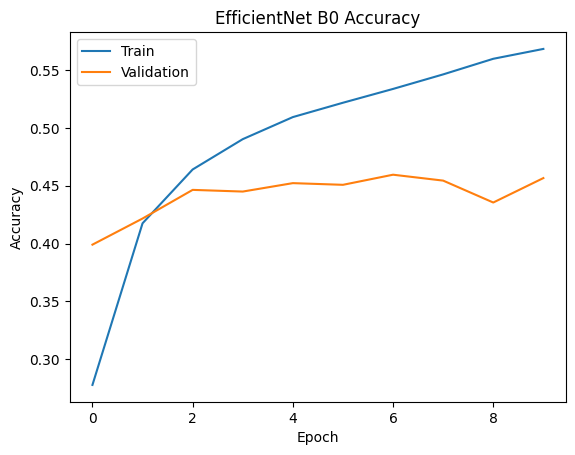

In [ ]:
train_acc = history_freeze_b0["train_acc"]
val_acc   = history_freeze_b0["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("EfficientNet B0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

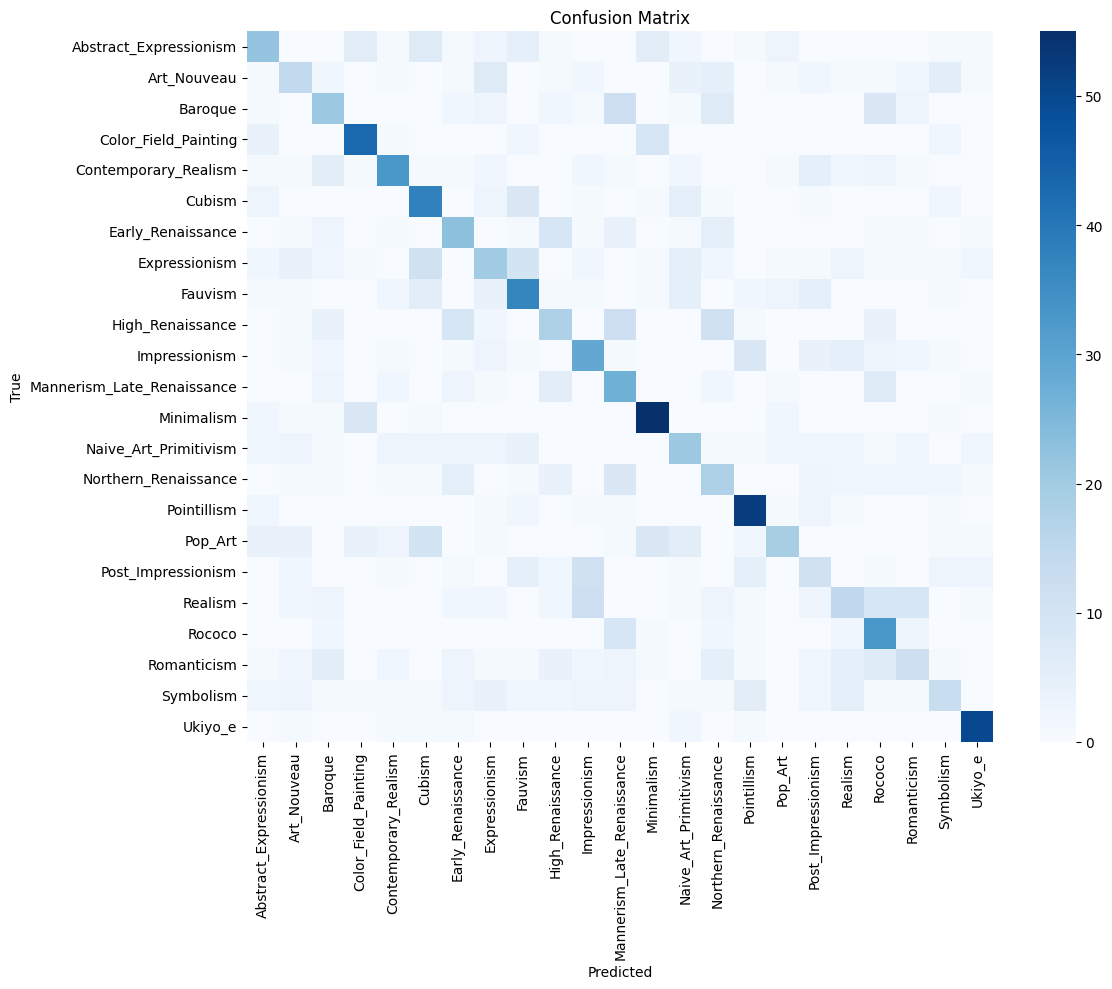

In [ ]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_b0,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)


In [ ]:
class_names = sorted(df_train["style_name"].unique())

acc_per_style = accuracy_per_class(
    model_b0,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")


Ukiyo_e: 0.877
Pointillism: 0.800
Minimalism: 0.775
Color_Field_Painting: 0.705
Rococo: 0.623
Cubism: 0.603
Fauvism: 0.529
Contemporary_Realism: 0.524
Mannerism_Late_Renaissance: 0.509
Impressionism: 0.468
Early_Renaissance: 0.442
Naive_Art_Primitivism: 0.375
Abstract_Expressionism: 0.367
Northern_Renaissance: 0.346
Baroque: 0.344
Pop_Art: 0.297
High_Renaissance: 0.290
Expressionism: 0.286
Art_Nouveau: 0.269
Post_Impressionism: 0.239
Symbolism: 0.232
Realism: 0.231
Romanticism: 0.203


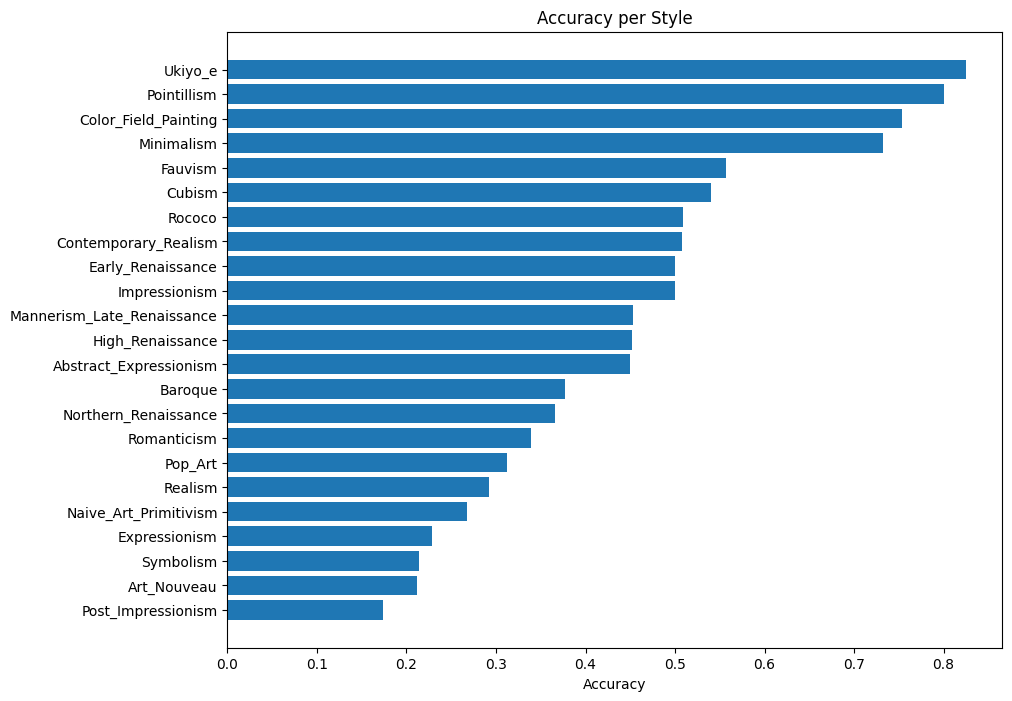

In [ ]:
visualize_accuracy_per_style(results)

#### 1.6.2 Evaluation sur l'ensemble de test

In [ ]:
best_model_weights = model_b0.state_dict()

test_acc, test_cm, report = evaluate_model(model_b0, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

Test Accuracy: 0.453
Classification Report:
                            precision    recall  f1-score   support

    Abstract_Expressionism     0.5385    0.4286    0.4773        49
               Art_Nouveau     0.2708    0.2364    0.2524        55
                   Baroque     0.3492    0.3667    0.3577        60
      Color_Field_Painting     0.5660    0.5882    0.5769        51
      Contemporary_Realism     0.5926    0.5614    0.5766        57
                    Cubism     0.5263    0.6667    0.5882        60
         Early_Renaissance     0.5309    0.6143    0.5695        70
             Expressionism     0.2000    0.2069    0.2034        58
                   Fauvism     0.3913    0.4909    0.4355        55
          High_Renaissance     0.3617    0.2931    0.3238        58
             Impressionism     0.3548    0.3188    0.3359        69
Mannerism_Late_Renaissance     0.4588    0.5821    0.5132        67
                Minimalism     0.7288    0.7818    0.7544        55
   

Test Confusion Matrix:


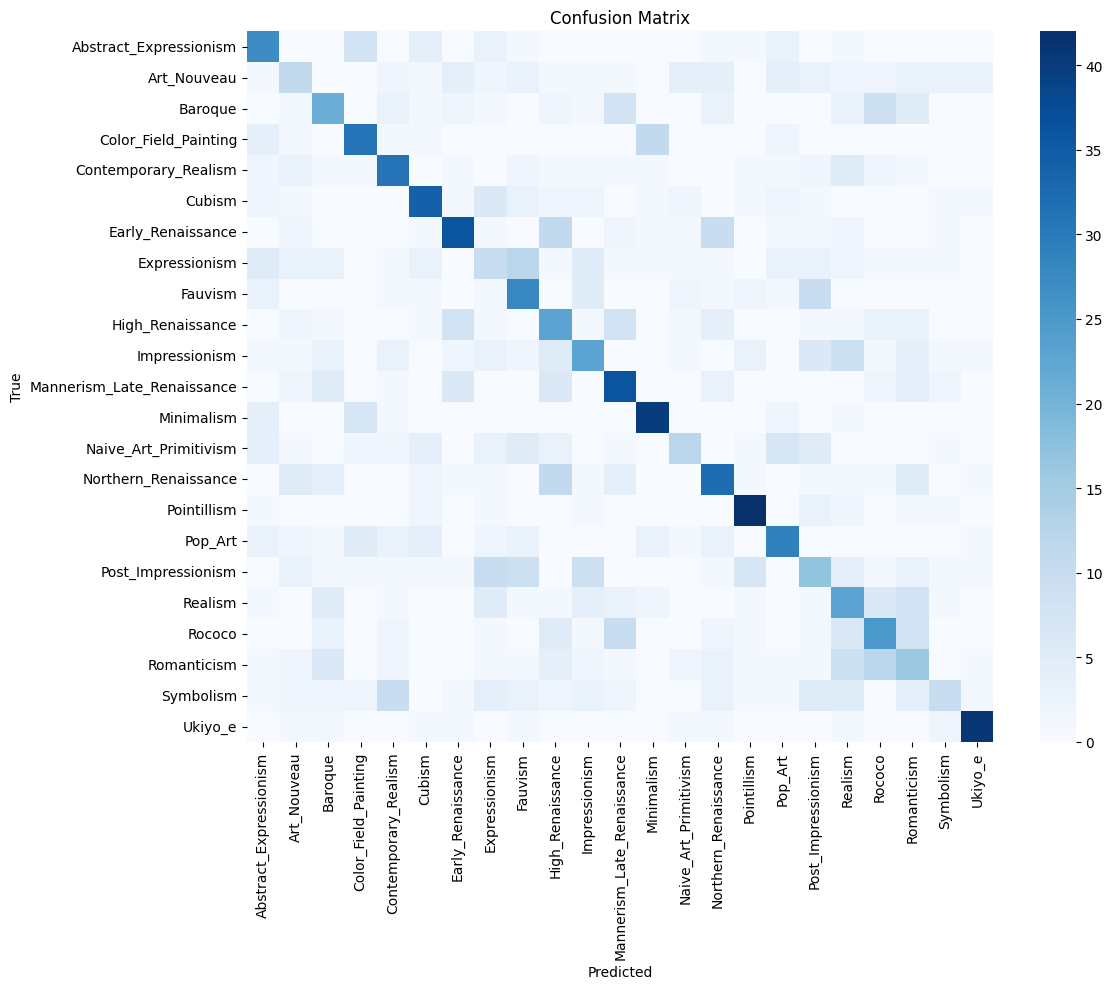

In [ ]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)

### Modele b1

In [ ]:
history_freeze_b1 = train_model(
    model_b1,
    train_loader,
    val_loader,
    criterion,
    optimizer_b1,
    device,
    num_epochs=NUM_EPOCHS_FREEZE,
    early_stopping=early_stopping
)


Epoch 1/10


Train Loss: 2.1528 | Train Acc: 0.4241 | Val Loss: 2.1613 | Val Acc: 0.4283
Early stopping triggered.


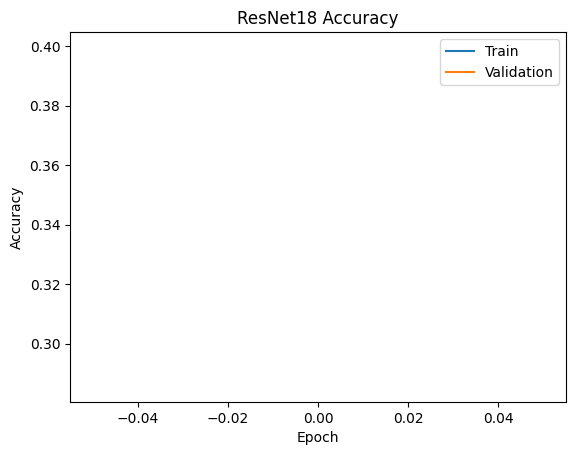

In [ ]:
train_acc = history_freeze_b1["train_acc"]
val_acc   = history_freeze_b1["val_acc"]

plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(["Train", "Validation"])
plt.title("ResNet18 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()



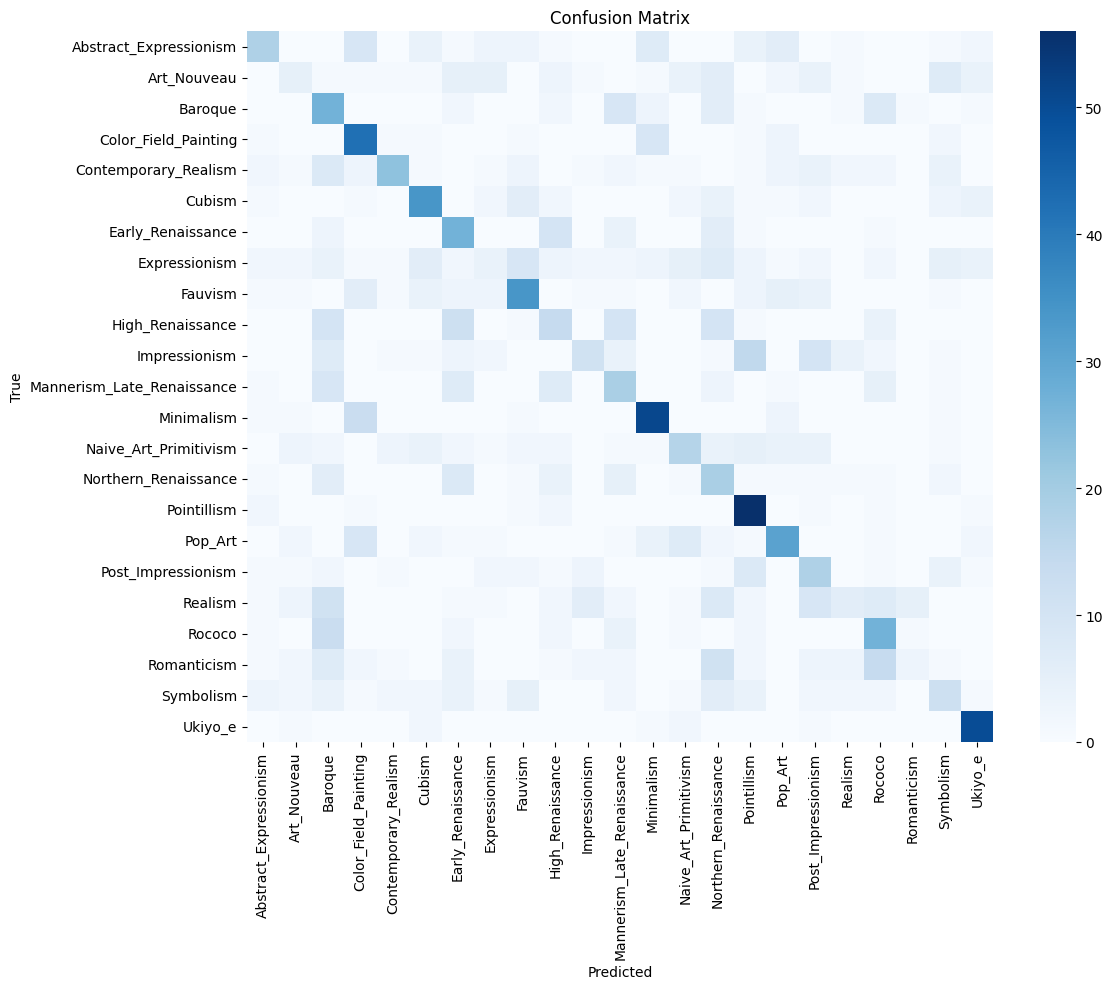

In [ ]:
#Confusion matrix :

class_names = sorted(df_train["style_name"].unique())

cm = compute_confusion_matrix(
    model_b1,
    val_loader,
    device,
    class_names
)

plot_confusion_matrix(cm, class_names)

In [ ]:

class_names = sorted(df_train["style_name"].unique())

acc_per_style = accuracy_per_class(
    model_b1,
    val_loader,
    device,
    class_names
)

results = list(zip(class_names, acc_per_style))
results = sorted(results, key=lambda x: x[1], reverse=True)

for style, acc in results:
    print(f"{style}: {acc:.3f}")

Ukiyo_e: 0.877
Pointillism: 0.862
Minimalism: 0.718
Color_Field_Painting: 0.689
Cubism: 0.540
Early_Renaissance: 0.519
Rococo: 0.509
Fauvism: 0.486
Pop_Art: 0.484
Baroque: 0.443
Post_Impressionism: 0.391
Northern_Renaissance: 0.365
Contemporary_Realism: 0.365
Mannerism_Late_Renaissance: 0.358
Naive_Art_Primitivism: 0.304
Abstract_Expressionism: 0.300
High_Renaissance: 0.226
Symbolism: 0.214
Impressionism: 0.177
Art_Nouveau: 0.096
Realism: 0.092
Expressionism: 0.057
Romanticism: 0.051


In [ ]:
visualize_accuracy_per_style(results)

#### Evaluation sur l'ensemble de test


In [ ]:
best_model_weights = model_mn.state_dict()

test_acc, test_cm, report = evaluate_model(model_mn, test_loader, device)

print(f"Test Accuracy: {test_acc:.3f}")
print("Classification Report:")
print(report)

In [ ]:
print("Test Confusion Matrix:")
plot_confusion_matrix(test_cm, class_names)

### Dataset avec ajout de data augmentation

In [ ]:
from torchvision import transforms

In [ ]:
transform_train_data_aug = transforms.Compose([
    # On redimensionne un peu plus grand
    transforms.Resize(256),

    # On découpe une zone aléatoire de 224x224
    # Simulation zoom sur les détails du tableau.
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    # Retournement horizontal (on inverse gauche/droite)
    transforms.RandomHorizontalFlip(p=0.5),

    # Variations de couleurs légères
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    # Conversion et Normalisation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [ ]:
IMAGE_ROOT_TRAIN = DATA_ROOT / "train"
IMAGE_ROOT_VAL = DATA_ROOT / "val"
IMAGE_ROOT_TEST = DATA_ROOT / "test"

train_dataset_aug = ArtDataset(
    df_train,
    IMAGE_ROOT_TRAIN,
    transform=transform_train_data_aug
)

val_dataset = ArtDataset(
    df_val,
    IMAGE_ROOT_VAL,
    transform=transform_val
)

test_dataset = ArtDataset(
    df_test,
    IMAGE_ROOT_TEST,
    transform=transform_val
)

NameError: name 'df_train' is not defined

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

Efficient b0 avec Data augmentation n°1 et entièrement freeze

In [ ]:
from src.train import train_model, unfreeze_last_layers, unfreeze_all

num_classes = df_train["style_encoded"].nunique()

model_eff = get_model("efficientnet_b0", num_classes=num_classes)
model_eff = model_eff.to(device)

model_eff.load_state_dict(torch.load("/content/efficientnet_phase1.pth", weights_only=True))
print("Poids phase 1 chargés")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Défreeze des derniers blocs
model_eff = unfreeze_last_layers(model_eff, "efficientnet_b0", num_blocks=3)

optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_eff.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2,
    mode='min',
    factor=0.3,
    patience=2
)

history_p2 = train_model(
    model_eff,
    train_loader,
    val_loader,
    criterion,
    optimizer_p2,
    device,
    num_epochs=15,
    scheduler=scheduler_p2
)

torch.save(model_eff.state_dict(), "/content/efficientnet_phase2_unfreeze3.pth")